# Original vs Projected Pairwise Distances (Two Data Fields)

This notebook compares pairwise Euclidean distances in:
- original 2-field space
- projected space

It follows helper logic from `gaussian_random_projection_search.py` (loader + distance + Gaussian random projection style).

In [16]:
from pathlib import Path
from itertools import combinations

try:
    import torch
except ImportError:
    torch = None

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

from sklearn.random_projection import (
    johnson_lindenstrauss_min_dim,
    SparseRandomProjection,
    GaussianRandomProjection,
)
from scipy.stats import pearsonr, spearmanr

from random_projection import load_raw_binary, euclidean_distance, gaussian_random_projection_fp16_cpu, gaussian_random_projection_fp16_gpu

sns.set_theme(style="whitegrid")

### 2) Load data and compute pair-wise distance

In [30]:
data_dir = "/home/jwang96/datasets/Hurricane_new/clean-data-Jinyang/"
field_name = ["CLOUD", "P", "PRECIP", "QCLOUD", "QGRAUP", "QICE", "QRAIN", "QSNOW", "QVAPOR", "TC", "U", "V", "W"]
# field_name = ["CLOUD", "PRECIP", "QCLOUD", "QGRAUP", "QICE", "QRAIN", "QSNOW", "QVAPOR", "TC", "U", "V", "W"]
projection_method = "sklearn_sparse"  # choices: ["manual_cpu", "manual_cuda", "sklearn_sparse", "sklearn_gaussian"]

timestep = 24
data_shape = (500, 500, 100)

field_vectors = {}
for field in field_name:
    input_file = f"{data_dir}/{field}/{field}f{timestep:02d}.bin"
    raw = load_raw_binary(input_file, dtype=np.float32, shape=data_shape)
    field_vectors[field] = raw.reshape(-1)

print(f"Loaded timestep f{timestep:02d} for {len(field_vectors)} fields")

n_samples = len(field_name)
eps = 0.1
min_components = johnson_lindenstrauss_min_dim(n_samples=n_samples, eps=eps)
print(f"Minimum number of components for Random Projection: {min_components}")

# performing Random Projection using the selected method
data_matrix = np.stack([field_vectors[field] for field in field_name], axis=0)
if projection_method == "manual_cuda":
    if torch is None or not torch.cuda.is_available():
        print("CUDA backend unavailable; falling back to manual CPU projection")
        projected_matrix = gaussian_random_projection_fp16_cpu(
            data_matrix,
            n_components=min_components,
            random_state=42,
            feature_block_size=50_000,
        )
        print("Projection backend: manual_cpu")
    else:
        projected_matrix = gaussian_random_projection_fp16_gpu(
            data_matrix,
            n_components=min_components,
            random_state=42,
            feature_block_size=50_000,
        )
        print("Projection backend: manual_cuda")
elif projection_method == "manual_cpu":
    projected_matrix = gaussian_random_projection_fp16_cpu(
        data_matrix,
        n_components=min_components,
        random_state=42,
        feature_block_size=50_000,
    )
    print("Projection backend: manual_cpu")
elif projection_method == "sklearn_sparse":
    transformer = SparseRandomProjection(n_components=min_components, random_state=42)
    projected_matrix = transformer.fit_transform(data_matrix).astype(np.float32)
    print("Projection backend: sklearn_sparse")
elif projection_method == "sklearn_gaussian":
    transformer = GaussianRandomProjection(n_components=min_components, random_state=42)
    projected_matrix = transformer.fit_transform(data_matrix).astype(np.float32)
    print("Projection backend: sklearn_gaussian")
else:
    raise ValueError(
        f"Unknown projection_method='{projection_method}'. "
        "Choose from: manual_cpu, manual_cuda, sklearn_sparse, sklearn_gaussian"
    )

projected_vectors = {
    field: projected_matrix[idx]
    for idx, field in enumerate(field_name)
}

# Build original and projected pair-wise distance matrices
for i, field_i in enumerate(field_name):
    for j, field_j in enumerate(field_name):
        dist_orig = euclidean_distance(field_vectors[field_i], field_vectors[field_j])

distance_original = np.zeros((n_samples, n_samples), dtype=np.float32)
distance_projected = np.zeros((n_samples, n_samples), dtype=np.float32)
for i, field_i in enumerate(field_name):
    for j, field_j in enumerate(field_name):
        dist_orig = euclidean_distance(field_vectors[field_i], field_vectors[field_j])
        distance_original[i, j] = dist_orig
        dist_proj = euclidean_distance(projected_vectors[field_i], projected_vectors[field_j])
        distance_projected[i, j] = dist_proj

diag_epsilon = np.float32(1e-3)
np.fill_diagonal(distance_original, diag_epsilon)
np.fill_diagonal(distance_projected, diag_epsilon)

Loaded timestep f24 for 13 fields
Minimum number of components for Random Projection: 2198
Projection backend: sklearn_sparse
euclidean_distance took 0.025469s
euclidean_distance took 0.028336s
euclidean_distance took 0.027464s
euclidean_distance took 0.027339s
euclidean_distance took 0.026577s
euclidean_distance took 0.026834s
euclidean_distance took 0.027107s
euclidean_distance took 0.027900s
euclidean_distance took 0.026565s
euclidean_distance took 0.028194s
euclidean_distance took 0.027087s
euclidean_distance took 0.027717s
euclidean_distance took 0.026301s
euclidean_distance took 0.027505s
euclidean_distance took 0.022531s
euclidean_distance took 0.029223s
euclidean_distance took 0.028579s
euclidean_distance took 0.027345s
euclidean_distance took 0.028504s
euclidean_distance took 0.028167s
euclidean_distance took 0.028293s
euclidean_distance took 0.028281s
euclidean_distance took 0.027843s
euclidean_distance took 0.028266s
euclidean_distance took 0.029655s
euclidean_distance took 

## 6) Plot Original vs Projected Distances (Pairwise)

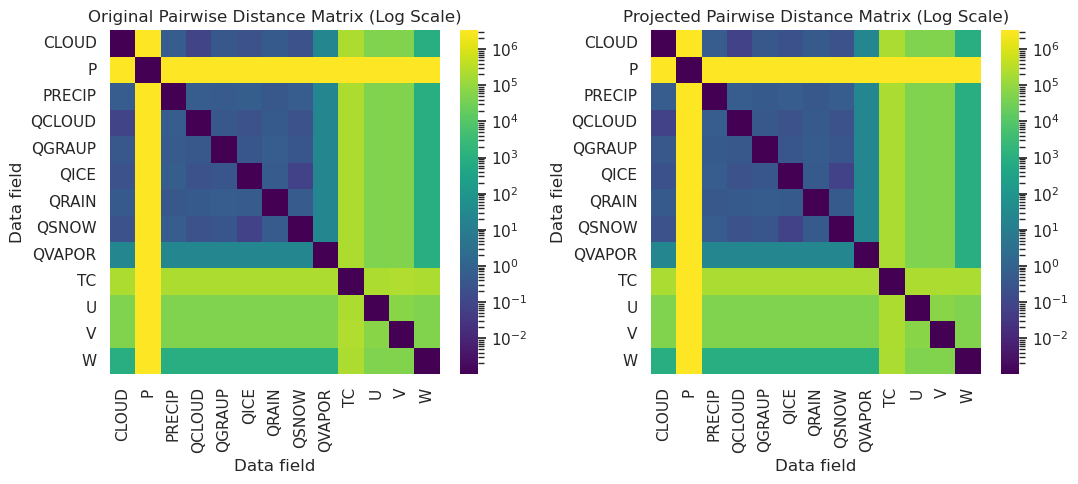

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

all_positive = np.concatenate([
    distance_original[distance_original > 0],
    distance_projected[distance_projected > 0],
])
if all_positive.size == 0:
    raise ValueError("All distances are zero; log scale requires positive values.")

vmin = all_positive.min()
vmax = all_positive.max()
norm = LogNorm(vmin=vmin, vmax=vmax)

sns.heatmap(distance_original, ax=axes[0], cmap='viridis', norm=norm)
axes[0].set_title('Original Pairwise Distance Matrix (Log Scale)')
axes[0].set_xlabel('Data field')
axes[0].set_ylabel('Data field')
axes[0].set_xticks(np.arange(n_samples) + 0.5)
axes[0].set_yticks(np.arange(n_samples) + 0.5)
axes[0].set_xticklabels(field_name, rotation=90, ha='center')
axes[0].set_yticklabels(field_name, rotation=0)

sns.heatmap(distance_projected, ax=axes[1], cmap='viridis', norm=norm)
axes[1].set_title('Projected Pairwise Distance Matrix (Log Scale)')
axes[1].set_xlabel('Data field')
axes[1].set_ylabel('Data field')
axes[1].set_xticks(np.arange(n_samples) + 0.5)
axes[1].set_yticks(np.arange(n_samples) + 0.5)
axes[1].set_xticklabels(field_name, rotation=90, ha='center')
axes[1].set_yticklabels(field_name, rotation=0)

plt.tight_layout()
plt.show()